# 06 - The final model and its one honest evaluation

**Split method:** the final model learns from all of `development.csv` (the earliest 80%, blocks 1 to 5); the test group (`test.csv`, the latest 20%) is used exactly once, later in this notebook, to report the final result. Every choice was already made with walk-forward validation in notebooks 04 and 05.

## Part 1: Training the final model

**Why it learns from everything before the test group:** the walk-forward rounds existed to *choose* (fix, model, features), so each had to hold later blocks back. With every choice locked in, nothing needs holding back:
1. **More to learn from:** 399 fraud cases, against 347 in the largest round.
2. **The most recent data matters most:** block 5 sits right before the test group, and fraud patterns shift over time, so the final model should see the period closest to the future it is judged on.
3. **It is how a real bank would work:** choose the approach by back-testing, then retrain on everything up to today before going live.

The test group is still completely unseen: the final model learns only from data that comes before it in time.

**The setup, unchanged from notebook 05:** XGBoost with its standard settings, the 29 features (V1 to V28 plus scaled Amount; hour_of_day was tested and left out), class weighting via `scale_pos_weight` = genuine ÷ fraud, and the Amount scaler, both now fitted on all the development data. `fit_final_model` (in `src/walk_forward.py`) builds the model with the same `make_model` as notebook 05, so the settings are guaranteed identical, and returns the trained model and the fitted scaler.

In [1]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd

from src.walk_forward import feature_columns, fit_final_model, prepare_with_scaler

print(sys.executable)

development = pd.read_csv("../data/processed/development.csv")
print(development.shape)

C:\Users\RevathyHarichandran\Desktop\portfolio projects\Fraud_detection\.venv\Scripts\python.exe


(226980, 34)


In [2]:
final_model, final_scaler = fit_final_model(development, feature_columns)

print(f"trained on {len(development):,} rows, {development['Class'].sum()} fraud")
print(f"scaler learned: Amount mean {final_scaler.mean_[0]:.2f}, spread {final_scaler.scale_[0]:.2f}")
print(f"scale_pos_weight: {final_model.get_params()['scale_pos_weight']:.1f}")
print(f"trees built: {final_model.get_booster().num_boosted_rounds()}")
print(f"features used: {len(feature_columns)}")

trained on 226,980 rows, 399 fraud
scaler learned: Amount mean 90.93, spread 250.77
scale_pos_weight: 567.9
trees built: 100
features used: 29


`mean_` and `scale_` are the two numbers the scaler learned (scikit-learn stores them in lists, one per column, so `[0]` takes Amount's). `get_booster().num_boosted_rounds()` asks XGBoost how many trees it actually built.

### Reproducibility check

Later phases (choosing a threshold, explaining the model) need exactly this final model. Rather than save and reload it before Phase 9, `fit_final_model` is called a second time; if the two copies give **identical scores** on the development data, any later phase can rebuild exactly the same model. (No performance score is reported on the development data: a model scored on data it learned from looks unrealistically good.)

In [3]:
second_model, second_scaler = fit_final_model(development, feature_columns)

development_X = prepare_with_scaler(development, final_scaler, feature_columns)
first_scores = final_model.predict_proba(development_X)[:, 1]
second_scores = second_model.predict_proba(development_X)[:, 1]

print("identical scores from both copies:", np.array_equal(first_scores, second_scores))

identical scores from both copies: True


## Part 2: The one-time test

**This is the first and only time `test.csv` is opened.** Committed in advance: nothing about the model, features or settings changes after seeing this result, whatever it is.

1. Keep only the rows outside the 10-minute gap (fixed in notebook 03): 55,372 rows, 74 fraud.
2. Prepare them with the **development-fitted** scaler (`prepare_with_scaler`: applied only, never refitted on test data).
3. Score every test transaction once with the final model.
4. **Save the scores immediately** to `data/staging/final_test_scores.csv` (`row_id`, `Class`, `score`). Every later step that needs test results (the precision-recall curve, MCC, applying the Phase 7 thresholds) reads this file instead of reopening `test.csv` or re-scoring, so the test group really is touched once.

In [4]:
test = pd.read_csv("../data/processed/test.csv")
test_scored = test[~test["in_gap"]]
print(f"test rows: {len(test):,} | scored (outside the gap): {len(test_scored):,} | fraud scored: {test_scored['Class'].sum()}")

test_X = prepare_with_scaler(test_scored, final_scaler, feature_columns)
test_scores = final_model.predict_proba(test_X)[:, 1]

final_test_scores = pd.DataFrame({
    "row_id": test_scored["row_id"].to_numpy(),
    "Class": test_scored["Class"].to_numpy(),
    "score": test_scores,
})
final_test_scores.to_csv("../data/staging/final_test_scores.csv", index=False)
print("saved", len(final_test_scores), "test scores to data/staging/final_test_scores.csv")

test rows: 56,746 | scored (outside the gap): 55,372 | fraud scored: 74
saved 55372 test scores to data/staging/final_test_scores.csv


### The headline result, with a bootstrap confidence interval

**AUCPR over recall 0 to 0.2** (the headline metric, explained in notebook 04): recall 0.2 of 74 fraud is about the first 15 fraud cases the model finds from its most confident flags. It answers: *working down the model's list of most suspicious transactions until about 15 frauds are found, how few genuine transactions get in the way?* 1.0 means none. **Average precision** (the whole curve, all 74 fraud) is the supporting number.

**Bootstrap:** 1,000 resamples of the 55,372 scored test rows, seed 42 (`bootstrap_metrics`, same method as every phase), for a 95% interval on each.

**Compared with notebook 05's pooled walk-forward result for XGBoost** (low-recall 0.9688, 95% CI 0.9116 to 1.0000; average precision 0.7527, 0.6940 to 0.8043). These come from **different transactions**, so the comparison is by whether the intervals overlap (no paired difference is possible).

In [5]:
from sklearn.metrics import average_precision_score

from src.walk_forward import aucpr_low_recall, bootstrap_metrics

recall_limit = 0.2
test_answers = final_test_scores["Class"].to_numpy()

test_low_recall = aucpr_low_recall(test_answers, test_scores, recall_limit)
test_average_precision = average_precision_score(test_answers, test_scores)

test_bootstrap = bootstrap_metrics(test_answers, {"final model": test_scores}, recall_limit, 1000, 42)
low_recall_list = test_bootstrap["final model"]["low_recall"]
ap_list = test_bootstrap["final model"]["average_precision"]

print("TEST GROUP (final model, 55,372 rows, 74 fraud):")
print(f"  low-recall AUCPR (recall 0 to 0.2): {test_low_recall:.4f}"
      f"  95% CI {np.percentile(low_recall_list, 2.5):.4f} to {np.percentile(low_recall_list, 97.5):.4f}")
print(f"  average precision (whole curve):    {test_average_precision:.4f}"
      f"  95% CI {np.percentile(ap_list, 2.5):.4f} to {np.percentile(ap_list, 97.5):.4f}")
print()
print("WALK-FORWARD, pooled (notebook 05, XGBoost, 176,175 rows, 250 fraud):")
print("  low-recall AUCPR (recall 0 to 0.2): 0.9688  95% CI 0.9116 to 1.0000")
print("  average precision (whole curve):    0.7527  95% CI 0.6940 to 0.8043")

TEST GROUP (final model, 55,372 rows, 74 fraud):
  low-recall AUCPR (recall 0 to 0.2): 1.0000  95% CI 1.0000 to 1.0000
  average precision (whole curve):    0.7991  95% CI 0.7129 to 0.8789

WALK-FORWARD, pooled (notebook 05, XGBoost, 176,175 rows, 250 fraud):
  low-recall AUCPR (recall 0 to 0.2): 0.9688  95% CI 0.9116 to 1.0000
  average precision (whole curve):    0.7527  95% CI 0.6940 to 0.8043


### How deep does a team have to go? (decided before the test group was opened)

A model doesn't "detect" fraud by itself; it scores every transaction, and detection depends on where the line is drawn. Catching 100% is always possible by flagging enough transactions, so the real question is **what it costs**: how many alerts must be reviewed to reach each share of the 74 frauds.

1. Sort the test transactions from most to least suspicious (`sort_values("score", ascending=False)`; `kind="stable"` keeps rows with tied scores in their original order, so the result is the same every run).
2. `cumsum()` (cumulative sum) runs down the `Class` column adding as it goes, so each position holds "frauds found so far".
3. For each target share, the frauds needed are rounded **up** to a whole case (`math.ceil`, so 80% of 74 = 59.2 becomes 60), and the first position where the running count reaches it is found: `(found_so_far >= needed).idxmax()` gives the first position where the test is `True`.
4. Alerts reviewed = that position + 1 (positions start at 0); precision there = frauds found ÷ alerts reviewed.

Purely descriptive: it changes no decision, and uses the same single scoring.

In [6]:
import math

ranked = final_test_scores.sort_values("score", ascending=False, kind="stable").reset_index(drop=True)
found_so_far = ranked["Class"].cumsum()
total_fraud = ranked["Class"].sum()

depth_rows = []
for target_share in [0.2, 0.5, 0.8, 1.0]:
    needed = math.ceil(target_share * total_fraud)
    position = (found_so_far >= needed).idxmax()

    # Self-check: the running count reaches `needed` exactly at this position, not before.
    if position > 0 and found_so_far[position - 1] >= needed:
        raise ValueError("depth calculation found the wrong position")

    alerts = position + 1
    depth_rows.append({
        "share of fraud caught": f"{target_share:.0%}",
        "frauds caught": needed,
        "alerts reviewed": alerts,
        "precision at that point": needed / alerts,
        "score of last alert": ranked.loc[position, "score"],
    })

depth_table = pd.DataFrame(depth_rows)
depth_table.to_csv("../outputs/tables/test_alert_depth.csv", index=False)
print(f"test group: {len(ranked):,} transactions, {total_fraud} fraud")
print(depth_table.round(4).to_string(index=False))

test group: 55,372 transactions, 74 fraud
share of fraud caught  frauds caught  alerts reviewed  precision at that point  score of last alert
                  20%             15               15                   1.0000               1.0000
                  50%             37               37                   1.0000               1.0000
                  80%             60              117                   0.5128               0.0121
                 100%             74            22970                   0.0032               0.0000


**What this shows** (reported exactly as it came out; nothing changed afterwards):
- **Headline: low-recall AUCPR 1.0000, 95% CI 1.0000 to 1.0000.** Working down the final model's list, the top alerts were all real fraud, far past the first 15: the depth table shows the first **37 alerts were all fraud** (half of the 74). Every bootstrap resample gave 1.0, so the interval collapses to a single point. **Honest caveat:** that does not mean the model is certain to be perfect on new data; it means this test group contains no example of a top alert being wrong, and the metric is at its ceiling, so it cannot show how much margin there is.
- **Average precision (whole curve, all 74 fraud): 0.7991, 95% CI 0.7129 to 0.8789.**
- **How deep a team must go:** 15 alerts catch 20% of the fraud and 37 catch 50%, all with no false alarms; 80% (60 frauds) takes 117 alerts, about half of them real fraud; **catching all 74 takes 22,970 alerts** (41% of all test transactions), with only 0.32% of those alerts being fraud. The last fraud case scored about 0.0000: the model considers it entirely ordinary.
- **Against the walk-forward result:** the test scores are higher (1.0000 against 0.9688; average precision 0.7991 against 0.7527), but the intervals overlap on both, so **the difference is not proven**. They are consistent with each other.
- **Why they can differ** (reasons stated before the test was opened): the final model learned from more data, including block 5 right before the test period; the test score comes from one model, while the walk-forward score pools four differently pitched round models; the test period (hours 40.3 to 48) has its own fraud rate and patterns; and with 74 fraud cases one test group can easily come out on the favourable side by chance.

## Part 3: The precision-recall curve on the test data

Uses the **saved scores** (`data/staging/final_test_scores.csv`), so `test.csv` is not reopened and nothing is re-scored.

**What the curve is:** picture the fraud team working down the model's list of most suspicious transactions. At every step, **recall** (across the bottom) is how much of the 74 fraud has been found so far, and **precision** (up the side) is how many of the alerts reviewed so far were real fraud. The curve traces that whole journey. The area under it is the average precision; the area under its left fifth (recall 0 to 0.2) is the headline metric.

- **Drawn as steps** (`drawstyle="steps-post"`): each step is one fraud case being found, and this is exactly how scikit-learn measures the area, so the picture and the numbers agree. A smooth line would suggest values in between that never happen.
- **The realistic range (recall 0 to 0.2)** is shaded with `axvspan` (a band across a stretch of the bottom axis).
- **Points from the depth table** (50%, 80% and 100% of fraud caught) are marked with `annotate`, which draws a label and a short arrow to a point.
- **Random guessing** (`axhline` at the test fraud rate, 74 ÷ 55,372 ≈ 0.13%): what a no-skill model scores at every recall.
- Axes run from 0 to 1 on both sides, so nothing is exaggerated by zooming in. (scikit-learn's ready-made `PrecisionRecallDisplay` draws a basic curve in one line, but can't mark the range or the depth points.)

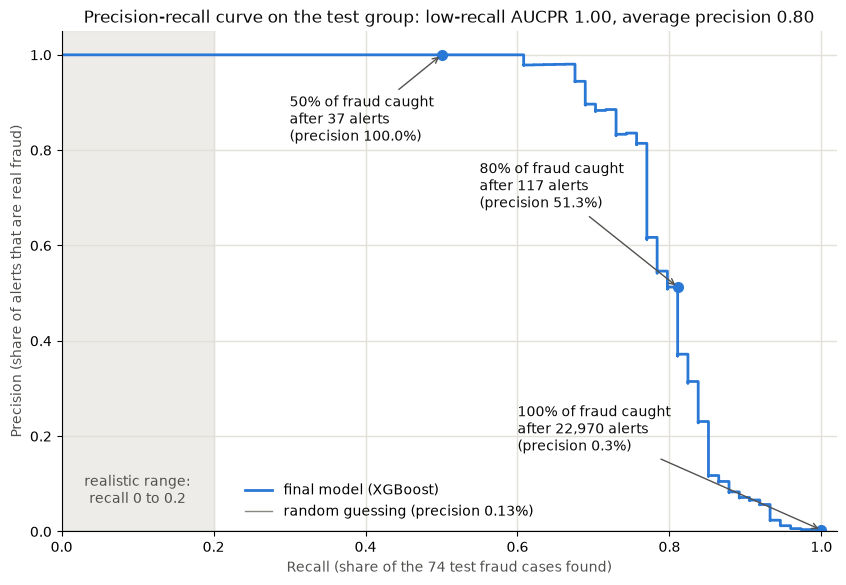

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

saved = pd.read_csv("../data/staging/final_test_scores.csv")
saved_answers = saved["Class"].to_numpy()
saved_scores = saved["score"].to_numpy()

precision, recall, thresholds = precision_recall_curve(saved_answers, saved_scores)
fraud_rate = saved_answers.mean()

depth = pd.read_csv("../outputs/tables/test_alert_depth.csv")
total_fraud = saved_answers.sum()

fig, ax = plt.subplots(figsize=(10, 6.5))

ax.axvspan(0, 0.2, color="#e1e0d9", alpha=0.6)
ax.text(0.1, 0.06, "realistic range:\nrecall 0 to 0.2", ha="center", color="#52514e")

ax.plot(recall, precision, drawstyle="steps-post", color="#2a78d6", linewidth=2, label="final model (XGBoost)")
ax.axhline(fraud_rate, color="#898781", linewidth=1, label=f"random guessing (precision {fraud_rate:.2%})")

# The 50%, 80% and 100% rows of the depth table, as points on the curve.
# Label positions are placed in empty space so no label crosses the curve.
label_positions = {"50%": (0.30, 0.82), "80%": (0.55, 0.68), "100%": (0.60, 0.17)}
for row_number in range(len(depth)):
    share = depth.loc[row_number, "share of fraud caught"]
    if share in label_positions:
        point_recall = depth.loc[row_number, "frauds caught"] / total_fraud
        point_precision = depth.loc[row_number, "precision at that point"]
        label = f"{share} of fraud caught\nafter {depth.loc[row_number, 'alerts reviewed']:,} alerts\n(precision {point_precision:.1%})"
        ax.annotate(label, xy=(point_recall, point_precision), xytext=label_positions[share],
                    color="#0b0b0b", arrowprops={"arrowstyle": "->", "color": "#52514e"})
        ax.plot(point_recall, point_precision, marker="o", markersize=7, color="#2a78d6")

ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall (share of the 74 test fraud cases found)", color="#52514e")
ax.set_ylabel("Precision (share of alerts that are real fraud)", color="#52514e")
ax.set_title(f"Precision-recall curve on the test group: low-recall AUCPR {test_low_recall:.2f}, average precision {test_average_precision:.2f}",
             color="#0b0b0b")
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0.22, 0.0))
ax.grid(color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.savefig("../outputs/figures/08_precision_recall_curve_test.png", dpi=150, bbox_inches="tight")
plt.show()

**What this shows:**
- **The shaded realistic range sits entirely on the flat line at precision 1.0**, which is what the headline score of 1.00 means: in the part of the list a time-limited team actually reviews, every alert was real fraud.
- **The flat line continues to recall 0.5 and beyond, to about 0.6** (around 45 of the 74 frauds) before the first false alarm appears.
- **From about recall 0.6 to 0.8 precision falls in steps** to 51% (60 frauds caught after 117 alerts): each step down is a run of genuine transactions the model ranked above the next fraud.
- **After recall 0.8 the curve collapses towards the random-guessing line** (0.13%): the last fraud cases look ordinary to the model, and catching all 74 means reviewing 22,970 alerts.
- **Rerunning this notebook re-executes Part 2's scoring**; the saved scores file's fingerprint was checked before and after each rerun and was unchanged, so no new information came from the test group.

## MCC: deferred to Phase 7

**MCC** (Matthews Correlation Coefficient) scores yes/no decisions using all four outcomes (fraud caught, fraud missed, false alarm, genuine let through), from −1 to +1. It is the project's secondary number, never the headline, because it depends on where the decision line (threshold) is drawn, and it blends in tens of thousands of easy genuine decisions, while the headline metric focuses on the top of the list a fraud team actually reviews.

Because it needs a threshold, and the threshold is chosen in Phase 7 on the walk-forward check blocks, MCC is reported there, at the chosen thresholds, using the saved test scores. Two other options were set aside: reporting it now at the arbitrary default line of 0.5, and finding the best-MCC threshold on the test data (ruled out: that would be choosing on the test group).